# 可选实验：多变量线性回归

在本实验中，你将扩展数据结构和之前开发的例程，使其支持多个特征。由于更新了多个例程，本实验看起来较长，但这些只是对旧例程的小幅调整，因此可以很快完成复习。
# 大纲
- [&nbsp;&nbsp;1.1 目标](#toc_15456_1.1)
- [&nbsp;&nbsp;1.2 工具](#toc_15456_1.2)
- [&nbsp;&nbsp;1.3 记号](#toc_15456_1.3)
- [2 问题陈述](#toc_15456_2)
- [&nbsp;&nbsp;2.1 包含样本的矩阵 X](#toc_15456_2.1)
- [&nbsp;&nbsp;2.2 参数向量 w、b](#toc_15456_2.2)
- [3 使用多变量进行模型预测](#toc_15456_3)
- [&nbsp;&nbsp;3.1 逐元素进行单次预测](#toc_15456_3.1)
- [&nbsp;&nbsp;3.2 使用向量进行单次预测](#toc_15456_3.2)
- [4 计算多变量代价](#toc_15456_4)
- [5 多变量梯度下降](#toc_15456_5)
- [&nbsp;&nbsp;5.1 计算多变量梯度](#toc_15456_5.1)
- [&nbsp;&nbsp;5.2 多变量梯度下降](#toc_15456_5.2)
- [6 恭喜](#toc_15456_6)

<a name="toc_15456_1.1"></a>
## 1.1 目标
- 扩展回归模型例程，使其支持多个特征：
    - 扩展数据结构以支持多个特征；
    - 重写预测、代价和梯度例程，使其支持多个特征；
    - 使用 NumPy `np.dot` 对实现进行向量化，以提高速度并简化代码。

<a name="toc_15456_1.2"></a>
## 1.2 工具
在本实验中，我们将使用：
- NumPy，一个常用的科学计算库
- Matplotlib，一个常用的数据绘图库

In [1]:
import copy, math
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')
np.set_printoptions(precision=2)  # reduced display precision on numpy arrays

## 1.3 记号

下面汇总了你将遇到的一些记号，并针对多特征情况进行了更新。

| 通用记号 | 描述 | Python（如适用） |
|------------------|-------------|------------------------|
| $a$ | 标量，非粗体 | |
| $\mathbf{a}$ | 向量，粗体 | |
| $\mathbf{A}$ | 矩阵，大写粗体 | |
| **回归** | | |
| $\mathbf{X}$ | 训练样本矩阵 | `X_train` |
| $\mathbf{y}$ | 训练样本目标值 | `y_train` |
| $\mathbf{x}^{(i)}, y^{(i)}$ | 第 $i$ 个训练样本 | `X[i]`, `y[i]` |
| $m$ | 训练样本数量 | `m` |
| $n$ | 每个样本中的特征数量 | `n` |
| $\mathbf{w}$ | 参数：权重 | `w` |
| $b$ | 参数：偏置 | `b` |
| $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$ | 模型输出：$f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = \mathbf{w} \cdot \mathbf{x}^{(i)} + b$ | `f_wb` |

<a name="toc_15456_2"></a>
# 2 问题陈述

你将使用房价预测这一启发性示例。训练数据集包含三个样本，每个样本有四个特征（面积、卧室数、楼层数和房龄），如下表所示。请注意，与之前的实验不同，这里的面积单位是平方英尺，而不是 1000 平方英尺。这会造成一个问题，你将在下一个实验中解决它！

| 面积（平方英尺） | 卧室数  | 楼层数 | 房龄 | 价格（千美元）  |
| ----------------| ------------------- |-----------------|--------------|-------------- |
| 2104            | 5                   | 1                | 45           | 460           |
| 1416            | 3                   | 2                | 40           | 232           |
| 852             | 2                   | 1                | 35           | 178           |

你将使用这些值构建一个线性回归模型，以预测其他房屋的价格。例如，一栋面积 1200 平方英尺、有 3 间卧室、1 层楼、房龄 40 年的房屋。

请运行以下代码单元格以创建 `X_train` 和 `y_train` 变量。

In [2]:
X_train = np.array([[2104, 5, 1, 45], [1416, 3, 2, 40], [852, 2, 1, 35]])
y_train = np.array([460, 232, 178])

<a name="toc_15456_2.1"></a>
## 2.1 包含样本的矩阵 X
与上表类似，样本存储在 NumPy 矩阵 `X_train` 中。矩阵的每一行表示一个样本。当有 $m$ 个训练样本（在我们的示例中 $m$ 为 3），并且有 $n$ 个特征（在我们的示例中为 4）时，$\mathbf{X}$ 是维度为（$m$, $n$）的矩阵（m 行、n 列）。


$$\mathbf{X} = 
\begin{pmatrix}
 x^{(0)}_0 & x^{(0)}_1 & \cdots & x^{(0)}_{n-1} \\ 
 x^{(1)}_0 & x^{(1)}_1 & \cdots & x^{(1)}_{n-1} \\
 \cdots \\
 x^{(m-1)}_0 & x^{(m-1)}_1 & \cdots & x^{(m-1)}_{n-1} 
\end{pmatrix}
$$
记号：
- $\mathbf{x}^{(i)}$ 是包含样本 i 的向量。$\mathbf{x}^{(i)}$ $ = (x^{(i)}_0, x^{(i)}_1, \cdots,x^{(i)}_{n-1})$
- $x^{(i)}_j$ 是样本 i 中的第 j 个元素。括号中的上标表示样本编号，下标表示元素。

显示输入数据。

In [3]:
# data is stored in numpy array/matrix
print(f"X Shape: {X_train.shape}, X Type:{type(X_train)})")
print(X_train)
print(f"y Shape: {y_train.shape}, y Type:{type(y_train)})")
print(y_train)

X Shape: (3, 4), X Type:<class 'numpy.ndarray'>)
[[2104    5    1   45]
 [1416    3    2   40]
 [ 852    2    1   35]]
y Shape: (3,), y Type:<class 'numpy.ndarray'>)
[460 232 178]


<a name="toc_15456_2.2"></a>
## 2.2 参数向量 w、b

* $\mathbf{w}$ 是包含 $n$ 个元素的向量。
  - 每个元素包含与一个特征关联的参数。
  - 在我们的数据集中，n 为 4。
  - 在记号中，我们将其画成列向量

$$\mathbf{w} = \begin{pmatrix}
w_0 \\ 
w_1 \\
\cdots\\
w_{n-1}
\end{pmatrix}
$$
* $b$ 是标量参数。  

为便于演示，将为 $\mathbf{w}$ 和 $b$ 加载一些接近最优值的初始选定值。$\mathbf{w}$ 是一维 NumPy 向量。

In [4]:
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])
print(f"w_init shape: {w_init.shape}, b_init type: {type(b_init)}")

w_init shape: (4,), b_init type: <class 'float'>


<a name="toc_15456_3"></a>
# 3 多变量模型预测
多变量模型的预测由以下线性模型给出：

$$ f_{\mathbf{w},b}(\mathbf{x}) =  w_0x_0 + w_1x_1 +... + w_{n-1}x_{n-1} + b \tag{1}$$
或使用向量记号：
$$ f_{\mathbf{w},b}(\mathbf{x}) = \mathbf{w} \cdot \mathbf{x} + b  \tag{2} $$ 
其中 $\cdot$ 是一个向量 `dot product`

为了演示点积，我们将分别使用 (1) 和 (2) 实现预测。

<a name="toc_15456_3.1"></a>
## 3.1 逐元素进行单次预测
之前的预测方法是将一个特征值乘以一个参数，再加上偏置参数。要将先前的预测实现直接扩展到多个特征，可以使用循环遍历每个元素，实现上面的公式 (1)：把每个元素与对应参数相乘，最后再加上偏置参数。

In [5]:
def predict_single_loop(x, w, b): 
    """
    single predict using linear regression
    
    Args:
      x (ndarray): Shape (n,) example with multiple features
      w (ndarray): Shape (n,) model parameters    
      b (scalar):  model parameter     
      
    Returns:
      p (scalar):  prediction
    """
    n = x.shape[0]
    p = 0
    for i in range(n):
        p_i = x[i] * w[i]  
        p = p + p_i         
    p = p + b                
    return p

In [6]:
# get a row from our training data
x_vec = X_train[0,:]
print(f"x_vec shape {x_vec.shape}, x_vec value: {x_vec}")

# make a prediction
f_wb = predict_single_loop(x_vec, w_init, b_init)
print(f"f_wb shape {f_wb.shape}, prediction: {f_wb}")

x_vec shape (4,), x_vec value: [2104    5    1   45]
f_wb shape (), prediction: 459.9999976194083


请注意 `x_vec` 的形状。它是一个包含 4 个元素的一维 NumPy 向量，形状为 (4,)。结果 `f_wb` 是一个标量。

<a name="toc_15456_3.2"></a>
## 3.2 单个预测（向量）

请注意，上面的方程 (1) 可以使用上面 (2) 中的点积来实现。我们可以利用向量运算加快预测速度。

回顾 Python/NumPy 实验中的内容，NumPy 的 `np.dot()` [[链接](https://numpy.org/doc/stable/reference/generated/numpy.dot.html)] 可用于计算向量点积。

In [7]:
def predict(x, w, b): 
    """
    single predict using linear regression
    Args:
      x (ndarray): Shape (n,) example with multiple features
      w (ndarray): Shape (n,) model parameters   
      b (scalar):             model parameter 
      
    Returns:
      p (scalar):  prediction
    """
    p = np.dot(x, w) + b     
    return p    

In [8]:
# get a row from our training data
x_vec = X_train[0,:]
print(f"x_vec shape {x_vec.shape}, x_vec value: {x_vec}")

# make a prediction
f_wb = predict(x_vec,w_init, b_init)
print(f"f_wb shape {f_wb.shape}, prediction: {f_wb}")

x_vec shape (4,), x_vec value: [2104    5    1   45]
f_wb shape (), prediction: 459.9999976194083


结果和形状与之前使用循环的版本相同。此后，将使用 `np.dot` 执行这些运算。现在，预测只需一条语句。大多数例程会直接实现它，而不是调用单独的 predict 例程。

<a name="toc_15456_4"></a>
# 4 计算多变量代价
多变量代价函数 $J(\mathbf{w},b)$ 的公式为：
$$J(\mathbf{w},b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})^2 \tag{3}$$ 
其中：
$$ f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = \mathbf{w} \cdot \mathbf{x}^{(i)} + b  \tag{4} $$ 


与之前的实验不同，$\mathbf{w}$ 和 $\mathbf{x}^{(i)}$ 是支持多特征的向量，而不是标量。

下面是公式 (3) 和 (4) 的实现。请注意，它采用了*本课程的标准模式*，即使用一个 for 循环遍历全部 `m` 个样本。

In [9]:
def compute_cost(X, y, w, b): 
    """
    compute cost
    Args:
      X (ndarray (m,n)): Data, m examples with n features
      y (ndarray (m,)) : target values
      w (ndarray (n,)) : model parameters  
      b (scalar)       : model parameter
      
    Returns:
      cost (scalar): cost
    """
    m = X.shape[0]
    cost = 0.0
    for i in range(m):                                
        f_wb_i = np.dot(X[i], w) + b           #(n,)(n,) = scalar (see np.dot)
        cost = cost + (f_wb_i - y[i])**2       #scalar
    cost = cost / (2 * m)                      #scalar    
    return cost

In [10]:
# Compute and display cost using our pre-chosen optimal parameters. 
cost = compute_cost(X_train, y_train, w_init, b_init)
print(f'Cost at optimal w : {cost}')

Cost at optimal w : 1.5578904428966628e-12


**预期结果**：最优 w 处的代价：1.5578904045996674e-12

<a name="toc_15456_5"></a>
# 5 多变量梯度下降
多变量梯度下降：

$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline\;
& w_j = w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \tag{5}  \; & \text{for j = 0..n-1}\newline
&b\ \ = b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b}  \newline \rbrace
\end{align*}$$

其中，n 是特征数量，参数 $w_j$、$b$ 同时更新，并且：

$$
\begin{align}
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})x_{j}^{(i)} \tag{6}  \\
\frac{\partial J(\mathbf{w},b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) \tag{7}
\end{align}
$$
* m 是数据集中的训练样本数量；

    
* $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$ 是模型的预测值，$y^{(i)}$ 是目标值。

<a name="toc_15456_5.1"></a>
## 5.1 计算多变量梯度
下面给出了计算公式 (6) 和 (7) 的一种实现。实现方法有很多。在此版本中：
- 外层循环遍历全部 m 个样本。
    - 可以直接计算并累加该样本的 $\frac{\partial J(\mathbf{w},b)}{\partial b}$
    - 在第二个循环中遍历全部 n 个特征：
        - 为每个 $w_j$ 计算 $\frac{\partial J(\mathbf{w},b)}{\partial w_j}$。

In [11]:
def compute_gradient(X, y, w, b): 
    """
    Computes the gradient for linear regression 
    Args:
      X (ndarray (m,n)): Data, m examples with n features
      y (ndarray (m,)) : target values
      w (ndarray (n,)) : model parameters  
      b (scalar)       : model parameter
      
    Returns:
      dj_dw (ndarray (n,)): The gradient of the cost w.r.t. the parameters w. 
      dj_db (scalar):       The gradient of the cost w.r.t. the parameter b. 
    """
    m,n = X.shape           #(number of examples, number of features)
    dj_dw = np.zeros((n,))
    dj_db = 0.

    for i in range(m):                             
        err = (np.dot(X[i], w) + b) - y[i]   
        for j in range(n):                         
            dj_dw[j] = dj_dw[j] + err * X[i, j]    
        dj_db = dj_db + err                        
    dj_dw = dj_dw / m                                
    dj_db = dj_db / m                                
        
    return dj_db, dj_dw

In [12]:
#Compute and display gradient 
tmp_dj_db, tmp_dj_dw = compute_gradient(X_train, y_train, w_init, b_init)
print(f'dj_db at initial w,b: {tmp_dj_db}')
print(f'dj_dw at initial w,b: \n {tmp_dj_dw}')

dj_db at initial w,b: -1.6739251501955248e-06
dj_dw at initial w,b: 
 [-2.73e-03 -6.27e-06 -2.22e-06 -6.92e-05]


**预期结果**：  
初始 w、b 处的 dj_db：-1.6739251122999121e-06  
初始 w、b 处的 dj_dw：  
 [-2.73e-03 -6.27e-06 -2.22e-06 -6.92e-05]  

<a name="toc_15456_5.2"></a>
## 5.2 多变量梯度下降
下面的例程实现了上面的公式 (5)。

In [19]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters): 
    """
    Performs batch gradient descent to learn theta. Updates theta by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      X (ndarray (m,n))   : Data, m examples with n features
      y (ndarray (m,))    : target values
      w_in (ndarray (n,)) : initial model parameters  
      b_in (scalar)       : initial model parameter
      cost_function       : function to compute cost
      gradient_function   : function to compute the gradient
      alpha (float)       : Learning rate
      num_iters (int)     : number of iterations to run gradient descent
      
    Returns:
      w (ndarray (n,)) : Updated values of parameters 
      b (scalar)       : Updated value of parameter 
      """
    
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    w = copy.deepcopy(w_in)  #avoid modifying global w within function
    b = b_in
    
    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_db,dj_dw = gradient_function(X, y, w, b)   ##None

        # Update Parameters using w, b, alpha and gradient
        w = w - alpha * dj_dw               ##None
        b = b - alpha * dj_db               ##None
      
        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            J_history.append( cost_function(X, y, w, b))

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]:8.2f}   ")
        
    return w, b, J_history #return final w,b and J history for graphing

在下一个单元格中，您将测试该实现。

In [20]:
# initialize parameters
initial_w = np.zeros_like(w_init)
initial_b = 0.
# some gradient descent settings
iterations = 1000
alpha = 5.0e-7
# run gradient descent 
w_final, b_final, J_hist = gradient_descent(X_train, y_train, initial_w, initial_b,
                                                    compute_cost, compute_gradient, 
                                                    alpha, iterations)
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")
m,_ = X_train.shape
for i in range(m):
    print(f"prediction: {np.dot(X_train[i], w_final) + b_final:0.2f}, target value: {y_train[i]}")

Iteration    0: Cost  2529.46   
Iteration  100: Cost   695.99   
Iteration  200: Cost   694.92   
Iteration  300: Cost   693.86   
Iteration  400: Cost   692.81   
Iteration  500: Cost   691.77   
Iteration  600: Cost   690.73   
Iteration  700: Cost   689.71   
Iteration  800: Cost   688.70   
Iteration  900: Cost   687.69   
b,w found by gradient descent: -0.00,[ 0.2   0.   -0.01 -0.07] 
prediction: 426.19, target value: 460
prediction: 286.17, target value: 232
prediction: 171.47, target value: 178


**预期结果**：    
梯度下降找到的 b、w：-0.00,[ 0.2   0.   -0.01 -0.07]   
预测值：426.19，目标值：460  
预测值：286.17，目标值：232  
预测值：171.47，目标值：178  

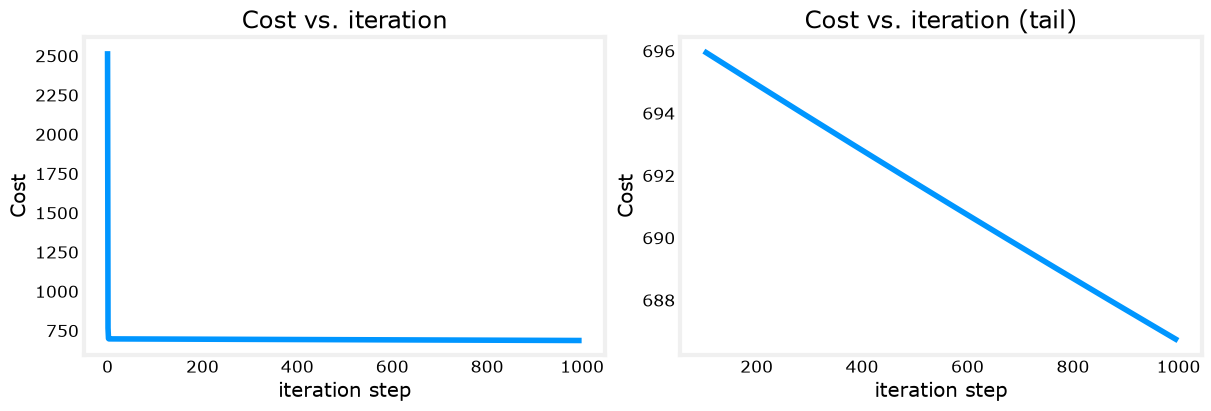

In [21]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step') 
plt.show()

*这些结果并不令人振奋*！代价仍在下降，而且预测并不十分准确。下一个实验将探索如何改进这一点。


<a name="toc_15456_6"></a>
# 6 恭喜！
在本实验中，您：
- 重新开发了线性回归例程，使其支持多个变量；
- 使用 NumPy `np.dot` 对实现进行了向量化。